# Milestone 3 — VoxCraft Parallel Evolution & Ablation Study

**Goal:** Evolve soft robot body plans using parallel voxelyze evaluation.
Evaluate all 6 ablation conditions to isolate the contribution of each EA component.

In [1]:
import os, json
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt

# Must set before any PyVista render call
pv.OFF_SCREEN = True

# Point to voxelyze binary (adjust path if needed)
os.environ.setdefault('VOXCRAFT_BIN', os.path.abspath('../voxelyze'))
print('VOXCRAFT_BIN:', os.environ.get('VOXCRAFT_BIN'))

# Change working dir to project root so imports resolve
import sys
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)
print('Project root:', project_root)

VOXCRAFT_BIN: /Users/hiremath/Documents/Projects_AI/xenobot_evolution/voxelyze
Project root: /Users/hiremath/Documents/Projects_AI/xenobot_evolution


## 1. Smoke test — single genome evaluation

In [2]:
from src.voxcraft_runner import evaluate_genome_m3

g = np.zeros((8, 8, 8), dtype=int)
for x in range(2, 6):
    for y in range(2, 6):
        for z in range(0, 4):
            g[x, y, z] = 2 if (x + y + z) % 2 == 0 else 3

score = evaluate_genome_m3(g, sim_time=0.5)
print(f'Test genome fitness: {score}')
assert score[0] > 0, 'Smoke test failed — check VOXCRAFT_BIN'

Test genome fitness: (0.736099,)


## 2. Quick pipeline test (3 generations, pop=5)

In [3]:
from src.milestone3.scaled_run import run_full_evolution

pop, log, hof = run_full_evolution(config={
    'pop_size': 5,
    'n_generations': 3,
    'n_workers': 2,
    'save_dir': 'results/m3/test/',
})
print(f'Quick run OK — best: {hof[0].fitness.values[0]:.4f}')

Gen 0 | Max: 9.4764 | Mean: 6.0768 | Div: 0.756
Quick run OK — best: 18.9833


## 3. Full overnight run

> **Estimated runtime:** ~6–10 hours on a Mac M-series (pop=30, 100 gens).
> Run overnight with:
> ```
> nohup python -m src.milestone3.scaled_run > results/m3/run.log 2>&1 &
> ```

In [4]:
# Uncomment to run (takes several hours)
pop, log, hof = run_full_evolution(config={
    'pop_size': 30,
    'n_generations': 100,
    'mu': 30,
    'lambda_': 60,
    'n_workers': 4,
    'save_dir': 'results/m3/',
})

Gen 0 | Max: 13.5969 | Mean: 5.3727 | Div: 0.751
Gen 5 | Max: 21.3620 | Mean: 18.5107 | Div: 0.404
Gen 10 | Max: 28.9409 | Mean: 27.6394 | Div: 0.013
Gen 15 | Max: 34.5627 | Mean: 34.0068 | Div: 0.021
Gen 20 | Max: 36.5012 | Mean: 35.7051 | Div: 0.026
Gen 25 | Max: 38.1469 | Mean: 37.5824 | Div: 0.019
Gen 30 | Max: 39.3402 | Mean: 39.2415 | Div: 0.003
Gen 35 | Max: 39.3402 | Mean: 39.3402 | Div: 0.000
Gen 40 | Max: 39.3402 | Mean: 39.3402 | Div: 0.000
Gen 45 | Max: 39.3402 | Mean: 39.3402 | Div: 0.000
Gen 50 | Max: 39.3402 | Mean: 39.3402 | Div: 0.000
Gen 55 | Max: 42.3533 | Mean: 39.6415 | Div: 0.007
Gen 60 | Max: 43.4576 | Mean: 43.4391 | Div: 0.002
Gen 65 | Max: 43.4576 | Mean: 43.4576 | Div: 0.000
Gen 70 | Max: 43.4576 | Mean: 43.4576 | Div: 0.000
Gen 75 | Max: 43.4576 | Mean: 43.4576 | Div: 0.000
Gen 80 | Max: 43.4576 | Mean: 43.4576 | Div: 0.000
Gen 85 | Max: 45.2443 | Mean: 44.7087 | Div: 0.001
Gen 90 | Max: 45.2443 | Mean: 45.2443 | Div: 0.000
Gen 95 | Max: 45.2443 | Mean: 45.2

In [12]:
pop, log, hof = run_full_evolution(config={
    'pop_size': 20,
    'n_generations': 50,
    'mu': 20,
    'lambda_': 40,
    'n_workers': 4,
    'tournsize': 3,
    'save_dir': 'results/m3/second_run',
})

Gen 0 | Max: 13.5969 | Mean: 5.1224 | Div: 0.751
Gen 5 | Max: 23.8120 | Mean: 17.6419 | Div: 0.125
Gen 10 | Max: 28.7323 | Mean: 24.8760 | Div: 0.041
Gen 15 | Max: 35.4579 | Mean: 31.7735 | Div: 0.070
Gen 20 | Max: 41.3082 | Mean: 38.3039 | Div: 0.047
Gen 25 | Max: 44.6741 | Mean: 40.8549 | Div: 0.035
Gen 30 | Max: 45.9577 | Mean: 43.5126 | Div: 0.025
Gen 35 | Max: 46.4707 | Mean: 45.5620 | Div: 0.009
Gen 40 | Max: 47.1647 | Mean: 46.6903 | Div: 0.004
Gen 45 | Max: 49.7032 | Mean: 47.8744 | Div: 0.018
Gen 50 | Max: 49.8833 | Mean: 49.7571 | Div: 0.007


## 4. Load and plot fitness curve

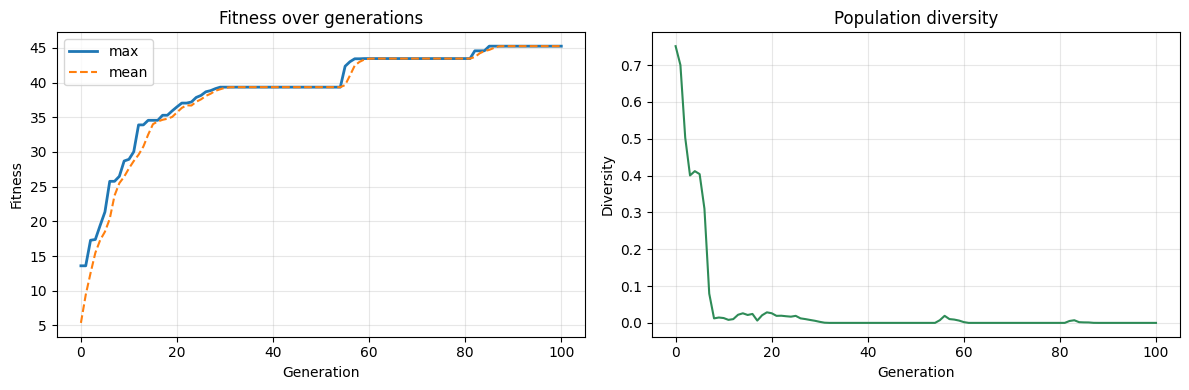

In [5]:
log_path = 'results/m3/full_run_log.json'
if os.path.exists(log_path):
    with open(log_path) as f:
        records = json.load(f)
    gens  = [r['gen']  for r in records]
    maxes = [r['max']  for r in records]
    means = [r['mean'] for r in records]
    divs  = [r.get('diversity', 0) for r in records]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(gens, maxes, label='max', linewidth=2)
    ax1.plot(gens, means, label='mean', linestyle='--')
    ax1.set_xlabel('Generation'); ax1.set_ylabel('Fitness')
    ax1.set_title('Fitness over generations'); ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot(gens, divs, color='seagreen')
    ax2.set_xlabel('Generation'); ax2.set_ylabel('Diversity')
    ax2.set_title('Population diversity'); ax2.grid(alpha=0.3)
    fig.tight_layout()
    os.makedirs('results/m3', exist_ok=True)
    fig.savefig('results/m3/fitness_curve.png', dpi=150)
    plt.show()
else:
    print(f'{log_path} not found — run the full evolution first.')

## 5. Render best robot

In [6]:
from src.Visualize import render_genome

best_path = 'results/m3/best_genome.npy'
if os.path.exists(best_path):
    best_genome = np.load(best_path)
    best_fit = hof[0].fitness.values[0] if 'hof' in dir() else 0.0
    render_genome(best_genome, title=f'Best robot  fit={best_fit:.4f}',
                  save_path='renders/m3/best_genome.png')
    print('Saved renders/m3/best_genome.png')
else:
    print('No best_genome.npy found — run full evolution first.')

Saved renders/m3/best_genome.png


## 6. Ablation study

6 conditions × 2 seeds = 12 runs. Each run: pop=20, 50 generations.
Estimated ~2–4 hours total on Mac.

In [7]:
from src.milestone3.ablation import run_all_ablations

# Uncomment to run (takes hours)
ablation_results = run_all_ablations(
    seeds=[42, 123],
    save_dir='results/m3/ablation/',
)
print('To run: uncomment the cell above.')

Running baseline seed 42 (1/12)...
  [baseline            ] seed=42 gen=  10 max=11.4527 div=0.0194
  [baseline            ] seed=42 gen=  20 max=14.3173 div=0.0352
  [baseline            ] seed=42 gen=  30 max=18.1463 div=0.0078
  [baseline            ] seed=42 gen=  40 max=21.1811 div=0.0066
  [baseline            ] seed=42 gen=  50 max=21.6314 div=0.0000
Running baseline seed 123 (2/12)...
  [baseline            ] seed=123 gen=  10 max=11.2317 div=0.0184
  [baseline            ] seed=123 gen=  20 max=18.1148 div=0.0047
  [baseline            ] seed=123 gen=  30 max=21.6358 div=0.0000
  [baseline            ] seed=123 gen=  40 max=22.5907 div=0.0000
  [baseline            ] seed=123 gen=  50 max=23.7871 div=0.0137
Running no_crossover seed 42 (3/12)...
  [no_crossover        ] seed=42 gen=  10 max=16.7643 div=0.0296
  [no_crossover        ] seed=42 gen=  20 max=18.2701 div=0.0000
  [no_crossover        ] seed=42 gen=  30 max=18.2701 div=0.0000
  [no_crossover        ] seed=42 gen=  4

AttributeError: module 'numpy' has no attribute 'trapz'

## 7. Plot ablation results

Saved ablation comparison → results/m3/ablation_comparison.png


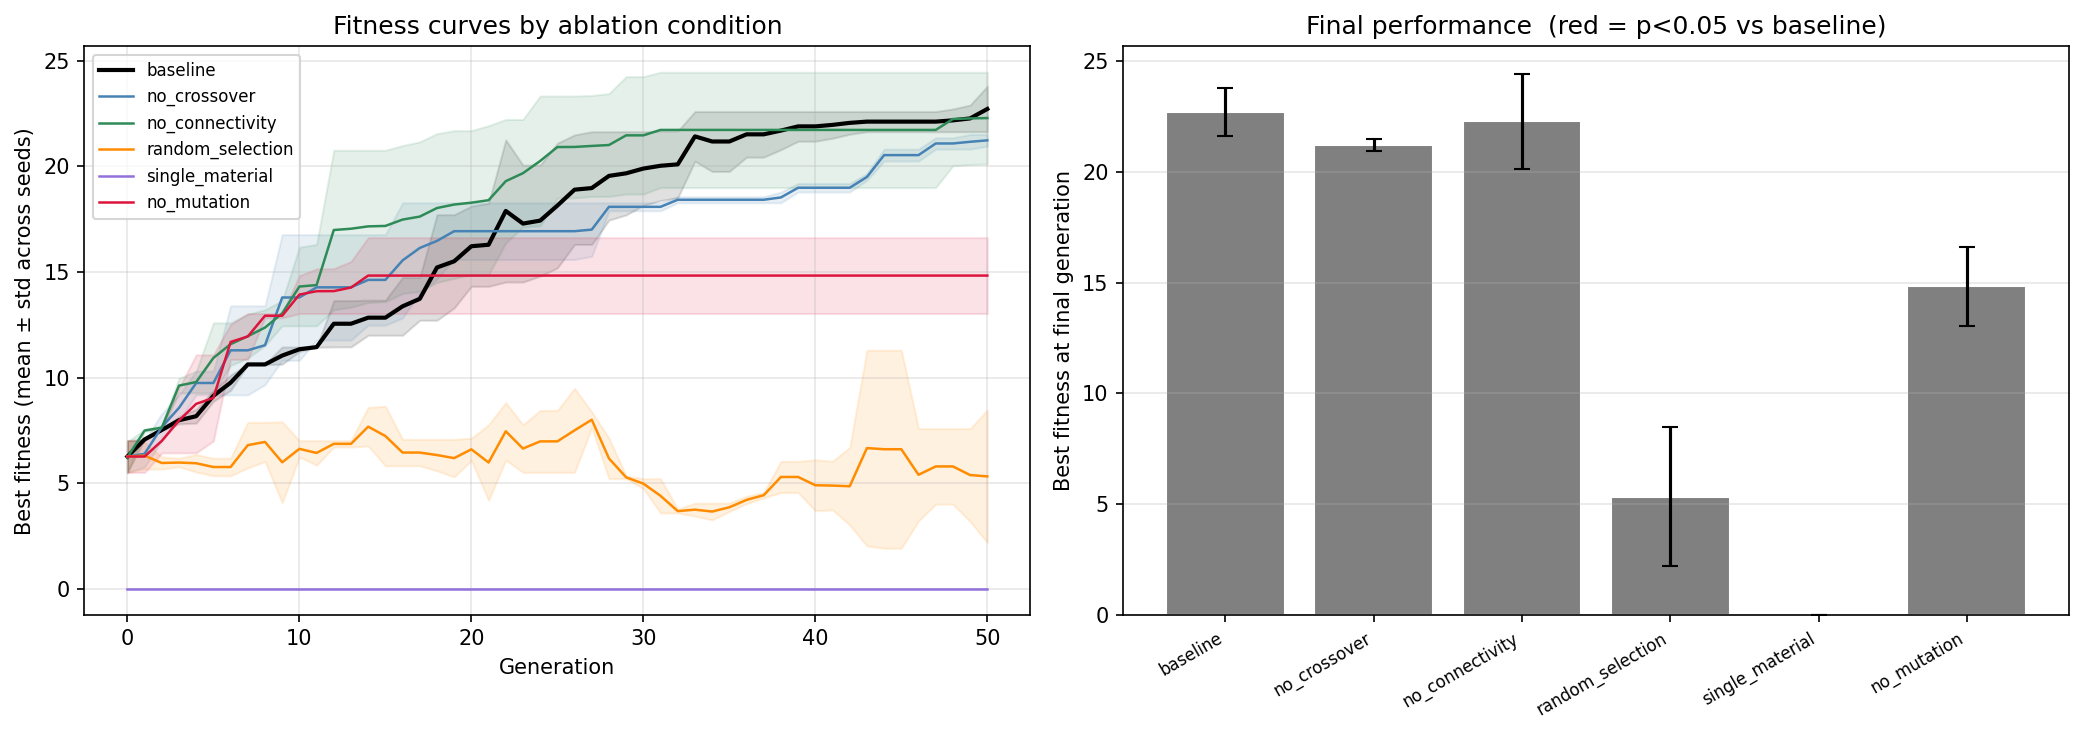

In [8]:
from src.milestone3.ablation import plot_ablation_results

ablation_dir = 'results/m3/ablation/'
if os.path.isdir(ablation_dir) and os.listdir(ablation_dir):
    plot_ablation_results(
        results_dir=ablation_dir,
        save_path='results/m3/ablation_comparison.png',
    )
    from IPython.display import Image
    display(Image('results/m3/ablation_comparison.png'))
else:
    print('No ablation results found — run ablation study first.')

## 8. Display ablation stats

In [10]:
%pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 60.9 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [11]:
import pandas as pd

stats_path = 'results/m3/ablation/ablation_stats.csv'
if os.path.exists(stats_path):
    df = pd.read_csv(stats_path)
    display(df.groupby('condition')[['best_fitness', 'auc_fitness']]
              .agg(['mean', 'std'])
              .round(4))
else:
    print('No ablation_stats.csv found.')

Empty DataFrame
Columns: [(best_fitness, mean), (best_fitness, std), (auc_fitness, mean), (auc_fitness, std)]
Index: []